In [1]:
# Compute SWE monthly mean trends !
# compute per year and store per month ?

In [47]:
import xarray as xr 
import numpy as np
import pymannkendall as mk
import glob
import os
#import rasterio
import rioxarray
import matplotlib.pyplot as plt
import bottleneck
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib.transforms as mtransforms
from cmcrameri import cm
from matplotlib import rc
from mpl_toolkits.axes_grid1 import ImageGrid

In [3]:
swe = xr.open_mfdataset(f'/mnt/data7/nfs4/avh_ndvi/sdupuis/swe/MERGED/v3.1/*/*/*-ESACCI-*.nc', engine='netcdf4')

In [ ]:
# do monthly max snow ! and save this! -> for above 50° north

In [ ]:
# sel arctic

In [21]:
swe_mo = swe['swe'].resample(time='1MS').max()

In [23]:
swe_mo_arctic = swe_mo.sel(lat=slice(50,85))

In [25]:
swe_mo_arctic

<xarray.DataArray 'swe' (time: 540, lat: 350, lon: 3600)>
dask.array<getitem, shape=(540, 350, 3600), dtype=float64, chunksize=(5, 350, 3600), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 50.05 50.15 50.25 50.35 ... 84.65 84.75 84.85 84.95
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.7 179.8 179.9
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-12-01
Attributes:
    long_name:            Snow Water Equivalent
    grid_mapping:         spatial_ref
    units:                mm
    valid_range:          [-30 500]
    flag_values:          [-30 -20 -10  -1   0]
    flag_meanings:        Glacier Mountain Water no_data no_snow
    ancillary_variables:  swe_std
    actual_range:         [  1 227]

In [12]:
# fractional snow cover
snow_data = f'/mnt/data6/nfs4/cci_snow_1/products/production_40_20250217/*/netcdf/scfg/*-*NOAA07-*.nc'
snow = xr.open_mfdataset(snow_data, chunks='auto', engine='netcdf4')

In [26]:
snow

<xarray.Dataset>
Dimensions:        (time: 1234, lat: 3600, nv: 2, lon: 7200)
Coordinates:
  * time           (time) datetime64[ns] 1981-08-24 1981-08-25 ... 1985-01-31
  * lat            (lat) float64 -89.97 -89.93 -89.88 ... 89.88 89.93 89.97
  * lon            (lon) float64 -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: nv
Data variables:
    lat_bnds       (time, lat, nv) float64 dask.array<chunksize=(1, 3600, 2), meta=np.ndarray>
    lon_bnds       (time, lon, nv) float64 dask.array<chunksize=(1, 7200, 2), meta=np.ndarray>
    scfg           (time, lat, lon) float32 dask.array<chunksize=(1, 3600, 7200), meta=np.ndarray>
    scfg_unc       (time, lat, lon) float32 dask.array<chunksize=(1, 3600, 7200), meta=np.ndarray>
    scanline_time  (time, lat, lon) float64 dask.array<chunksize=(1, 2895, 5794), meta=np.ndarray>
    satzen         (time, lat, lon) float64 dask.array<chunksize=(1, 2895, 5794), meta=np.ndarray>
    spatial_ref    (time) int32 -2147483647 -2147483647 ... -2147483647
Attributes: (12/42)
    title:                      ESA CCI snow on ground product level L3C from...
    institution:                Remote Sensing Research Group, Institute of G...
    source:                     EUMETSAT (2023): AVHRR Fundamental Data Recor...
    date_created:               20250218T011500Z
    history:                    20250218T011500Z: ESA snow_cci SCF processing...
    references:                 http://snow-cci.enveo.at/
    ...                         ...
    license:                    ESA CCI Data Policy: free and open access
    platform:                   NOAA-7 > National Oceanic & Atmospheric Admin...
    sensor:                     AVHRR > Advanced Very High Resolution Radiometer
    spatial_resolution:         0.05 degree
    key_variables:              scfg
    doi:                        10.5285/80d96e3a14854420b6f742d70877c431

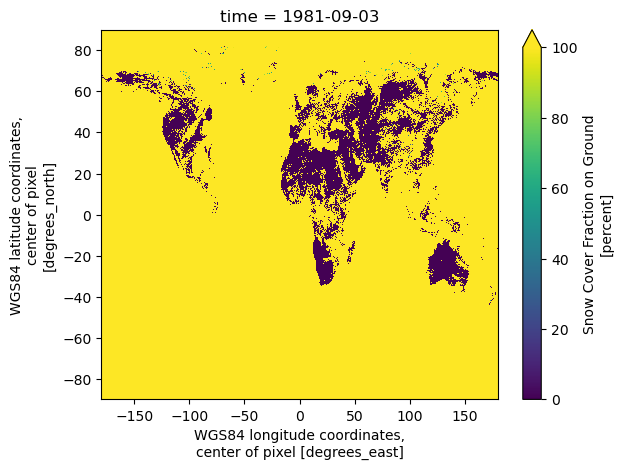

In [51]:
snow['scfg'].isel(time=10).plot(vmax=100);

In [14]:
snow_noaa09 = xr.open_mfdataset(f'/mnt/data6/nfs4/cci_snow_1/products/production_40_20250217/*/netcdf/scfg/*-*NOAA09-*.nc', chunks='auto', engine='netcdf4')

In [39]:
snow_noaa09 = snow_noaa09.sel(time=slice('1985', '1988-10-31'))

In [15]:
snow_noaa11 = xr.open_mfdataset(f'/mnt/data6/nfs4/cci_snow_1/products/production_40_20250217/*/netcdf/scfg/*-*NOAA11-*.nc', chunks='auto', engine='netcdf4')

In [28]:
snow_noaa11

<xarray.Dataset>
Dimensions:        (time: 2143, lat: 3600, nv: 2, lon: 7200)
Coordinates:
  * time           (time) datetime64[ns] 1988-11-08 1988-11-09 ... 1994-10-07
  * lat            (lat) float64 -89.97 -89.93 -89.88 ... 89.88 89.93 89.97
  * lon            (lon) float64 -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: nv
Data variables:
    lat_bnds       (time, lat, nv) float64 dask.array<chunksize=(1, 3600, 2), meta=np.ndarray>
    lon_bnds       (time, lon, nv) float64 dask.array<chunksize=(1, 7200, 2), meta=np.ndarray>
    scfg           (time, lat, lon) float32 dask.array<chunksize=(1, 3600, 7200), meta=np.ndarray>
    scfg_unc       (time, lat, lon) float32 dask.array<chunksize=(1, 3600, 7200), meta=np.ndarray>
    scanline_time  (time, lat, lon) float64 dask.array<chunksize=(1, 2895, 5794), meta=np.ndarray>
    satzen         (time, lat, lon) float64 dask.array<chunksize=(1, 2895, 5794), meta=np.ndarray>
    spatial_ref    (time) int32 -2147483647 -2147483647 ... -2147483647
Attributes: (12/42)
    title:                      ESA CCI snow on ground product level L3C from...
    institution:                Remote Sensing Research Group, Institute of G...
    source:                     EUMETSAT (2023): AVHRR Fundamental Data Recor...
    date_created:               20250219T193000Z
    history:                    20250219T193000Z: ESA snow_cci SCF processing...
    references:                 http://snow-cci.enveo.at/
    ...                         ...
    license:                    ESA CCI Data Policy: free and open access
    platform:                   NOAA-11 > National Oceanic & Atmospheric Admi...
    sensor:                     AVHRR > Advanced Very High Resolution Radiometer
    spatial_resolution:         0.05 degree
    key_variables:              scfg
    doi:                        10.5285/80d96e3a14854420b6f742d70877c431

In [16]:
snow_noaa14 = xr.open_mfdataset(f'/mnt/data6/nfs4/cci_snow_1/products/production_40_20250217/*/netcdf/scfg/*-*NOAA14-*.nc', chunks='auto', engine='netcdf4')

In [30]:
snow_noaa14 = snow_noaa14.sel(time=slice('1995', '2000'))

In [17]:
snow_noaa16 = xr.open_mfdataset(f'/mnt/data6/nfs4/cci_snow_1/products/production_40_20250217/*/netcdf/scfg/*-*NOAA16-*.nc', chunks='auto', engine='netcdf4')

In [34]:
snow_noaa16 = snow_noaa16.sel(time=slice('2001', '2005'))

In [18]:
snow_noaa18 = xr.open_mfdataset(f'/mnt/data6/nfs4/cci_snow_1/products/production_40_20250217/*/netcdf/scfg/*-*NOAA18-*.nc', chunks='auto', engine='netcdf4')

In [36]:
snow_noaa18 = snow_noaa18.sel(time=slice('2006', '2009'))

In [19]:
snow_noaa19 = xr.open_mfdataset(f'/mnt/data6/nfs4/cci_snow_1/products/production_40_20250217/*/netcdf/scfg/*-*NOAA19-*.nc', chunks='auto', engine='netcdf4')

In [38]:
snow_noaa19 = snow_noaa19.sel(time=slice('2010', '2018'))

In [53]:
results = {}

for nb in ['09', '11', '14', '16', '18', '19']:

    ds = globals()[f"snow_noaa"+nb]   



    #print(ds)
    clean_snow = ds['scfg'].where(ds['scfg'] < 101, np.nan)

    max_10d = (
        clean_snow
        .resample(
            time='1MS'
        )
        .mean()
    )

    # Ensure bins exist even with no data
    # Xarray automatically creates them and fills with NaN

    results[nb] = max_10d



In [54]:
results

{'09': <xarray.DataArray 'scfg' (time: 45, lat: 3600, lon: 7200)>
 dask.array<stack, shape=(45, 3600, 7200), dtype=float32, chunksize=(1, 3600, 7200), chunktype=numpy.ndarray>
 Coordinates:
   * lat      (lat) float64 -89.97 -89.93 -89.88 -89.82 ... 89.88 89.93 89.97
   * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0
   * time     (time) datetime64[ns] 1985-02-01 1985-03-01 ... 1988-10-01
 Attributes:
     long_name:            Snow Cover Fraction on Ground
     units:                percent
     standard_name:        surface_snow_area_fraction
     valid_range:          [  0 254]
     actual_range:         [  0 100]
     flag_values:          [205 206 210 215 254]
     flag_meanings:        Cloud Polar_Night_or_Night Water Permanent_Snow_and...
     grid_mapping:         spatial_ref
     ancillary_variables:  scfg_unc,
 '11': <xarray.DataArray 'scfg' (time: 72, lat: 3600, lon: 7200)>
 dask.array<stack, shape=(72, 3600, 7200), dtype=float32, chunksize=(1, 360

In [55]:
clean_snow_07 = snow['scfg'].where(snow['scfg'] < 101, np.nan)
max_10d = (clean_snow_07.resample(time='1MS').mean())

    # Ensure bins exist even with no data
    # Xarray automatically creates them and fills with NaN

results['07'] = max_10d

In [56]:
combined = xr.concat([results[y] for y in ['07','09', '11', '14', '16', '18', '19']], dim="time")

In [57]:
combined

<xarray.DataArray 'scfg' (time: 447, lat: 3600, lon: 7200)>
dask.array<concatenate, shape=(447, 3600, 7200), dtype=float32, chunksize=(1, 3600, 7200), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -89.97 -89.93 -89.88 -89.82 ... 89.88 89.93 89.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0
  * time     (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
Attributes:
    long_name:            Snow Cover Fraction on Ground
    units:                percent
    standard_name:        surface_snow_area_fraction
    valid_range:          [  0 254]
    actual_range:         [  0 100]
    flag_values:          [205 206 210 215 254]
    flag_meanings:        Cloud Polar_Night_or_Night Water Permanent_Snow_and...
    grid_mapping:         spatial_ref
    ancillary_variables:  scfg_unc

In [59]:
combined_arctic = combined.sel(lat=slice(50,85))

In [60]:
combined_arctic

<xarray.DataArray 'scfg' (time: 447, lat: 700, lon: 7200)>
dask.array<getitem, shape=(447, 700, 7200), dtype=float32, chunksize=(1, 700, 7200), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 50.03 50.08 50.12 50.17 ... 84.82 84.88 84.93 84.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0
  * time     (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
Attributes:
    long_name:            Snow Cover Fraction on Ground
    units:                percent
    standard_name:        surface_snow_area_fraction
    valid_range:          [  0 254]
    actual_range:         [  0 100]
    flag_values:          [205 206 210 215 254]
    flag_meanings:        Cloud Polar_Night_or_Night Water Permanent_Snow_and...
    grid_mapping:         spatial_ref
    ancillary_variables:  scfg_unc

In [63]:
climatology

<xarray.DataArray 'scfg' (month: 12, lat: 700, lon: 7200)>
dask.array<stack, shape=(12, 700, 7200), dtype=float32, chunksize=(1, 700, 7200), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 50.03 50.08 50.12 50.17 ... 84.82 84.88 84.93 84.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:            Snow Cover Fraction on Ground
    units:                percent
    standard_name:        surface_snow_area_fraction
    valid_range:          [  0 254]
    actual_range:         [  0 100]
    flag_values:          [205 206 210 215 254]
    flag_meanings:        Cloud Polar_Night_or_Night Water Permanent_Snow_and...
    grid_mapping:         spatial_ref
    ancillary_variables:  scfg_unc

In [64]:
anomalies

<xarray.DataArray 'scfg' (time: 447, lat: 700, lon: 7200)>
dask.array<sub, shape=(447, 700, 7200), dtype=float32, chunksize=(1, 700, 7200), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 50.03 50.08 50.12 50.17 ... 84.82 84.88 84.93 84.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0
  * time     (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
    month    (time) int64 8 9 10 11 12 1 2 3 4 5 6 ... 2 3 4 5 6 7 8 9 10 11 12

In [65]:
clim_std

<xarray.DataArray 'scfg' (month: 12, lat: 700, lon: 7200)>
dask.array<stack, shape=(12, 700, 7200), dtype=float32, chunksize=(1, 700, 7200), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 50.03 50.08 50.12 50.17 ... 84.82 84.88 84.93 84.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:            Snow Cover Fraction on Ground
    units:                percent
    standard_name:        surface_snow_area_fraction
    valid_range:          [  0 254]
    actual_range:         [  0 100]
    flag_values:          [205 206 210 215 254]
    flag_meanings:        Cloud Polar_Night_or_Night Water Permanent_Snow_and...
    grid_mapping:         spatial_ref
    ancillary_variables:  scfg_unc

In [61]:
# compute snow anomalies
climatology = combined_arctic.groupby('time.month').mean("time")

anomalies = combined_arctic.groupby('time.month') - climatology

clim_std = combined_arctic.groupby('time.month').std("time")

/local/sdupuis/software/conda/envs/rioxarray_env/lib/python3.11/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 38 times more chunks
  return self.array[key]


In [66]:
stand_anomalies = xr.apply_ufunc(
    lambda x, m, s: (x - m) / s,
    combined_arctic.groupby("time.month"),
    climatology,
    clim_std,
    dask="parallelized"
)

standard_anoms_scfg = stand_anomalies.compute()

/local/sdupuis/software/conda/envs/rioxarray_env/lib/python3.11/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/tmp/ipykernel_1361/2269129001.py:2: RuntimeWarning: invalid value encountered in divide
  lambda x, m, s: (x - m) / s,


: 

In [15]:
anoms_scfg = xr.open_dataset('output_data/standard_anoms_scfg.nc')

In [34]:
anoms_swe = xr.open_dataset('output_data/standard_anoms_swe.nc')

In [39]:
anoms_swe_interp = anoms_swe.interp(lat=std_anoms_day.coords['lat'], lon=std_anoms_day.coords['lon'], method='nearest')

In [40]:
anoms_swe_interp

<xarray.Dataset>
Dimensions:      (time: 540, lat: 200, lon: 200)
Coordinates:
  * time         (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-12-01
    month        (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
  * lat          (lat) float32 60.03 60.08 60.12 60.17 ... 69.88 69.93 69.97
  * lon          (lon) float32 -150.0 -149.9 -149.9 ... -140.1 -140.1 -140.0
    band         int64 1
    spatial_ref  int64 0
Data variables:
    swe          (time, lat, lon) float64 nan nan nan nan ... nan nan nan nan

In [16]:
std_anoms_day = xr.open_dataset('../anomaly_cubes/output_data/standard_anomalies_Greenland_day.nc')

In [17]:
std_anoms_day = std_anoms_day.sel(lat=slice(60,70), lon=slice(-150,-140))

In [41]:
import xarray as xr

# Align datasets (CRITICAL)
da1, da2 = xr.align(anoms_swe_interp, std_anoms_day, join="inner")



In [42]:
da1, da2

(<xarray.Dataset>
 Dimensions:      (time: 446, lat: 200, lon: 200)
 Coordinates:
   * time         (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
   * lat          (lat) float32 60.03 60.08 60.12 60.17 ... 69.88 69.93 69.97
   * lon          (lon) float32 -150.0 -149.9 -149.9 ... -140.1 -140.1 -140.0
     month        (time) int64 8 9 10 11 12 1 2 3 4 5 ... 3 4 5 6 7 8 9 10 11 12
     band         int64 1
     spatial_ref  int64 0
 Data variables:
     swe          (time, lat, lon) float64 nan nan nan nan ... nan nan nan nan,
 <xarray.Dataset>
 Dimensions:      (time: 446, lat: 200, lon: 200)
 Coordinates:
   * time         (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
   * lat          (lat) float32 60.03 60.08 60.12 60.17 ... 69.88 69.93 69.97
   * lon          (lon) float32 -150.0 -149.9 -149.9 ... -140.1 -140.1 -140.0
     band         int64 1
     spatial_ref  int64 0
     month        (time) int64 ...
 Data variables:
     LST          (lat, lon, time) f

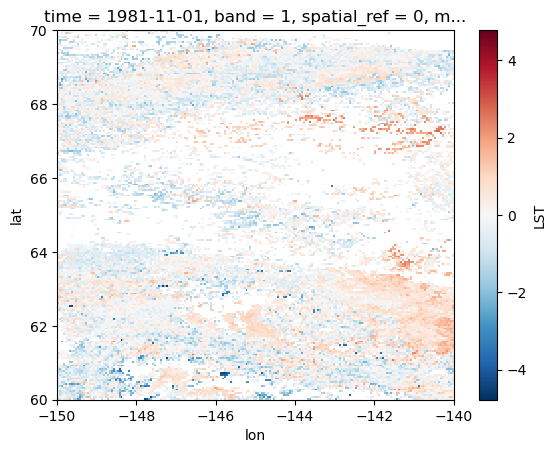

In [43]:
da2['LST'].isel(time=3).plot()

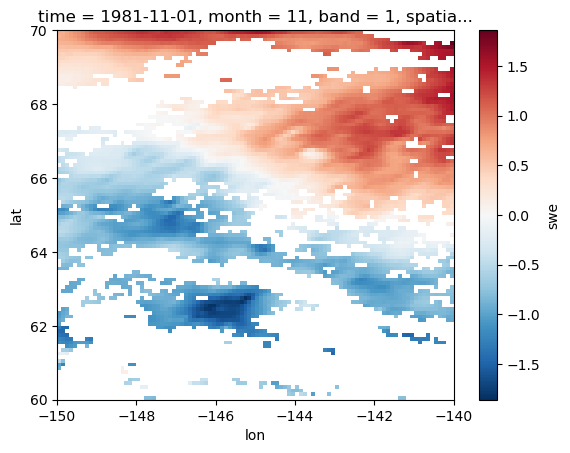

In [44]:
da1['swe'].isel(time=3).plot()

In [45]:
# Compute Pearson correlation along time
corr_map = xr.corr(da1['swe'], da2['LST'], dim="time")

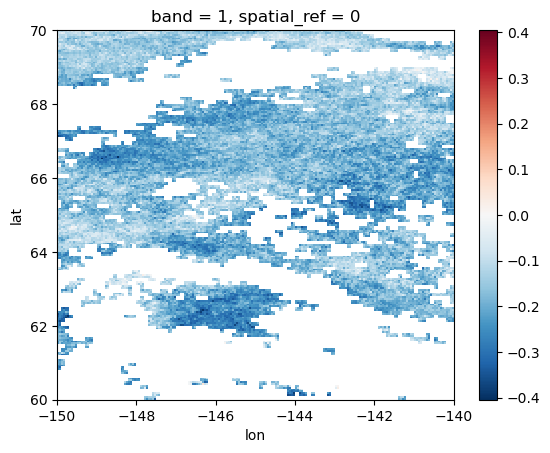

In [46]:
corr_map.plot();

In [24]:
corr_map_all = xr.open_dataset('corr_map_scfg.nc')

In [57]:
corr_map_swe = xr.open_dataset('corr_map_swe.nc')

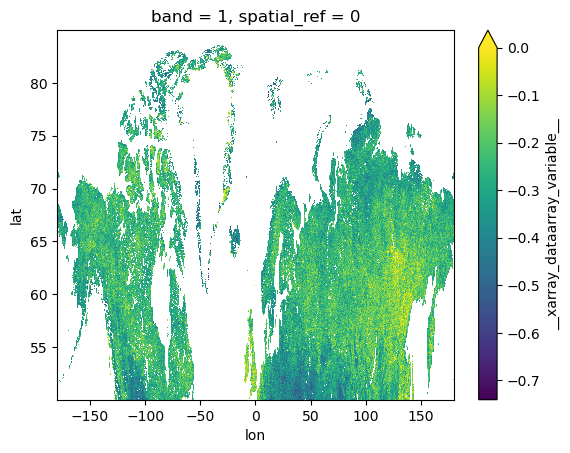

In [28]:
corr_map_all['__xarray_dataarray_variable__'].plot(vmax=0);

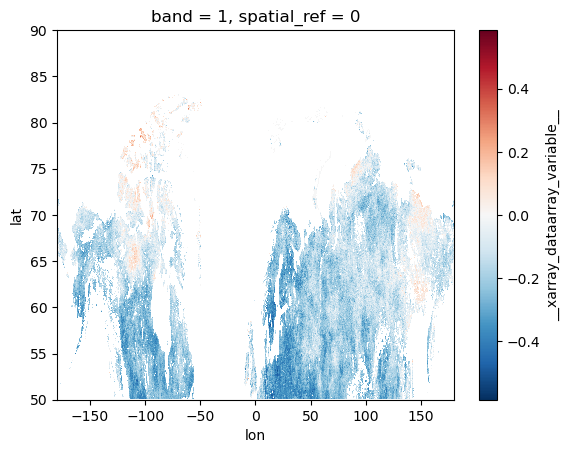

In [59]:
corr_map_swe['__xarray_dataarray_variable__'].plot();

/tmp/ipykernel_15433/1524506467.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


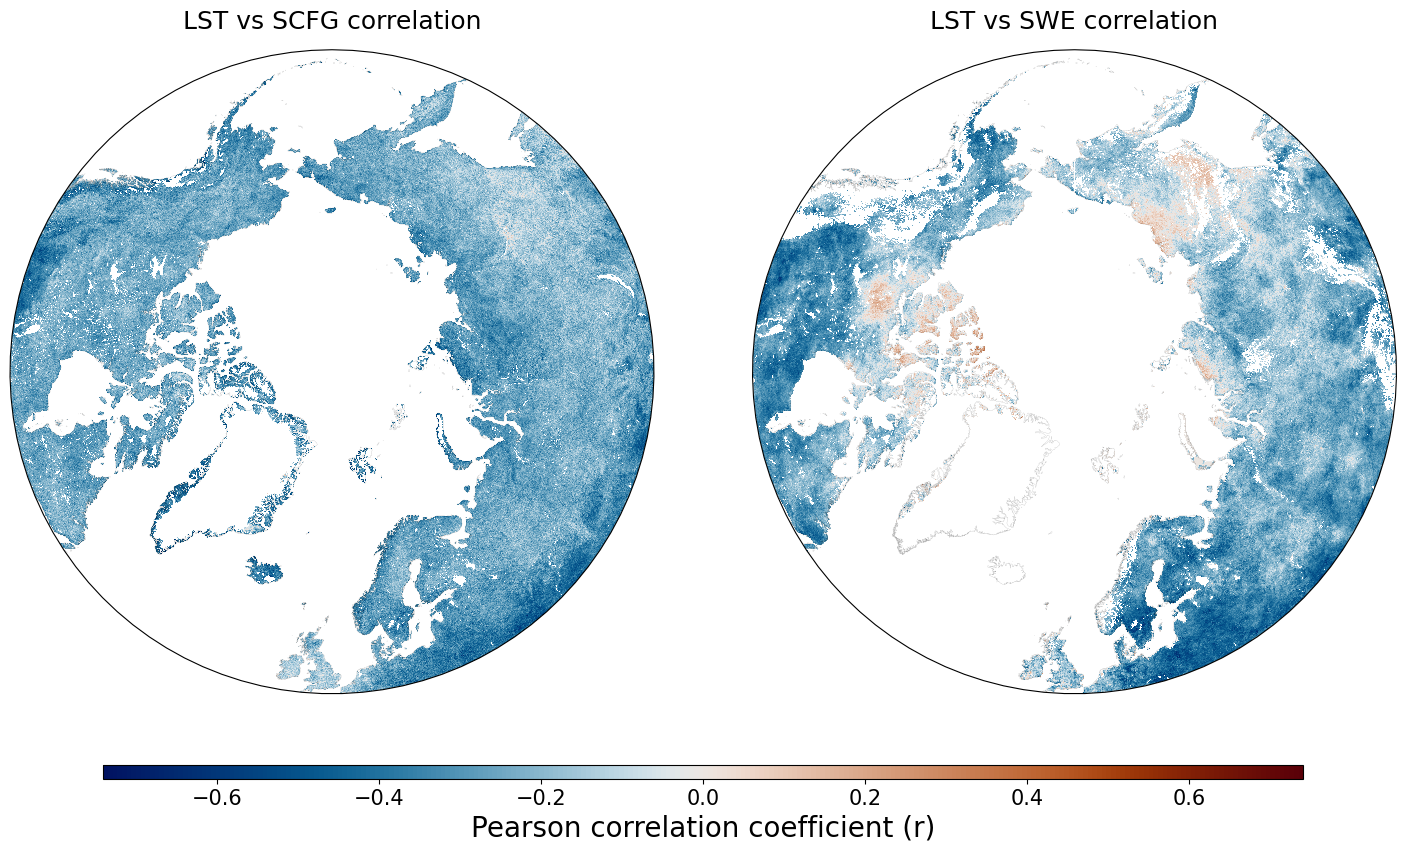

In [67]:
from cmcrameri import cm

fig, axs = plt.subplot_mosaic([['(a)', '(b)']],figsize=(15,7), subplot_kw=dict(projection=ccrs.Orthographic(0, 90), facecolor="white"))

fg = corr_map_all['__xarray_dataarray_variable__'].plot.pcolormesh(

    transform=ccrs.PlateCarree(),cmap=cm.vik,add_colorbar=False, ax=axs['(a)'])

#p.axes.set_global()
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

axs['(a)'].set_boundary(circle, transform=axs['(a)'].transAxes)

axs['(a)'].coastlines(zorder=3, color='black', linewidth=0.1, alpha=0.5, resolution='10m');
axs['(a)'].set_title('LST vs SCFG correlation', fontsize=18, pad=15);

corr_map_swe['__xarray_dataarray_variable__'].plot.pcolormesh(

    transform=ccrs.PlateCarree(), cmap=cm.vik, add_colorbar=False,ax=axs['(b)'])


axs['(b)'].set_boundary(circle, transform=axs['(b)'].transAxes)

axs['(b)'].coastlines(zorder=3, color='black', linewidth=0.1, alpha=0.5, resolution='10m');
axs['(b)'].set_title('LST vs SWE correlation',fontsize=18, pad=15);



#cb = plt.colorbar(fg, ax=axs, orientation="horizontal", pad=0.15)
#cbar = fig.colorbar(fg,  orientation="horizontal", label = 'units', shrink = 1)
#cb.set_label(label='Temperature ($^{\circ}$C)', size='large', weight='bold')
#cb.ax.tick_params(labelsize='large')
# color bar
fig.subplots_adjust(right=0.875) #also try using kwargs bottom, top, or hspace 
cbar_ax = fig.add_axes([0.1, -0.1, .8, .02]) #left, bottom, width, height
cb = fig.colorbar(fg, cax=cbar_ax, orientation="horizontal")
cb.set_label(label='Pearson correlation coefficient (r)', size=20)
#"LST Trend [degree decade$^{-1}$]"
cb.ax.tick_params(labelsize=15)
    

plt.tight_layout()
plt.savefig('snow_correl.png', format='png', dpi=300, bbox_inches='tight',pad_inches=0.1)
plt.savefig('snow_correl.pdf', format='pdf', dpi=300, bbox_inches='tight',pad_inches=0.1)



In [15]:
anoms_scfg

<xarray.Dataset>
Dimensions:  (lat: 700, lon: 7200, time: 447)
Coordinates:
  * lat      (lat) float64 50.03 50.08 50.12 50.17 ... 84.82 84.88 84.93 84.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0
  * time     (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
    month    (time) int64 ...
Data variables:
    scfg     (time, lat, lon) float32 ...

In [11]:
anoms_swe = xr.open_dataset('output_data/standard_anoms_swe.nc')

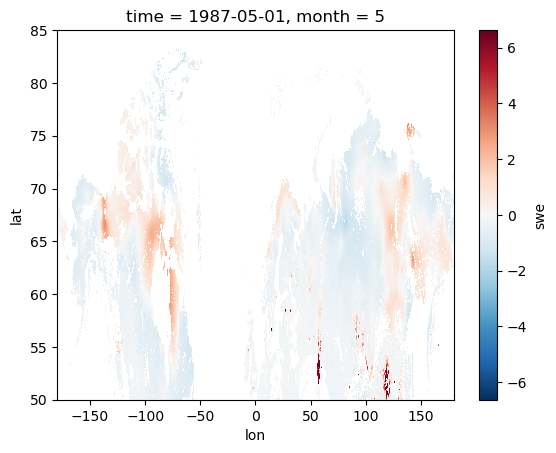

In [14]:
anoms_swe['swe'].isel(time=100).plot();

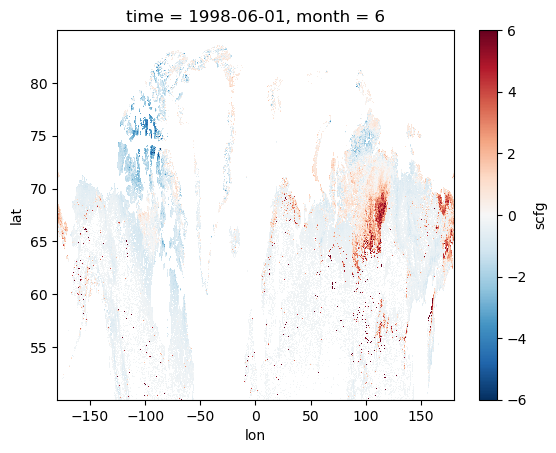

In [10]:
anoms_scfg['scfg'].isel(time=200).plot();